# RAMEN tutorial

This tutorial demonstrates the main RAMEN workflow using the recommended defaults. See the [RAMEN API documentation](https://ramen20.readthedocs.io/en/latest/api.html) for additional options.


## 1. Initialize RAMEN

Start by creating a RAMEN object from the input data. `csv_data` and `end_string` are required inputs; `min_values` is optional and its default is shown explicitly here:

- `csv_data`: path to the input CSV file. A relative path is resolved from the notebook's working directory; an absolute path may also be used.
- `end_string`: exact name of the outcome column in the CSV file.
- `min_values`: minimum number of non-missing observations required to retain a variable. Its default, `0`, keeps all variables.


In [1]:
from ramen.Ramen import Ramen

ramen_bowl = Ramen(
    csv_data="tutorial_data.csv",
    end_string="Long Covid",
    min_values=0,
)


Starting removing vars with too few values, vectorizing dataframe, and initializing mutual information matrix, this might take a few minutes.
Removed 0 variables because of insufficient data. If deleted too many, please adjust the min_values
done


## 2. Perform absorbing random walks to obtain network skeleton

Next, use absorbing random walks to select candidate edges for the initial network skeleton. The call below shows the recommended defaults. With `num_steps=None`, RAMEN calls `choose_steps` to select 3 to 9 steps from the number of variables retained after initialization; users may provide an integer to override this choice. `num_walks`, `p_value`, and `correction` control the number of walks, significance threshold, and multiple-testing correction. More walks or a larger step limit increases runtime.


In [2]:
ramen_bowl.random_walk(
    num_walks=50_000,
    num_steps=None,
    p_value=0.05,
    correction="no_correction",
)


Optimization terminated successfully.
         Current function value: 4.286639
         Iterations: 12
         Function evaluations: 13
         Gradient evaluations: 13


## 3. Refine the network using the genetic algorithm

RAMEN then refines the random-walk skeleton by evolving candidate networks. The recommended default parameters are used here; additional options are described in the API documentation.

In [3]:
ramen_bowl.genetic_algorithm(    
    num_candidates=10,
    reg_factor=0.01,
    hard_stop=100,
)


23
initializing scorer
done initializing scorer
making candidates
Finished making candidates in: 0.06814160000067204
starting Genetic Algorithm
-19.85769381726668
generation: 0 best: -18.97823627008869
generation: 1 best: -18.3698178413883
generation: 2 best: -18.367630241966438
generation: 3 best: -18.062527098715545
generation: 4 best: -17.825368924425767
generation: 5 best: -17.492336135944438
generation: 6 best: -17.28414184881827
generation: 7 best: -16.79940936299431
generation: 8 best: -16.525294218493872
generation: 9 best: -16.502181594069917
generation: 10 best: -15.957696281248134
generation: 11 best: -15.574797163340822
generation: 12 best: -15.407233181006932
generation: 13 best: -15.338067363377085
generation: 14 best: -15.131465041557242
generation: 15 best: -14.92095149377483
generation: 16 best: -14.732603582875278
generation: 17 best: -14.699030292703409
generation: 18 best: -14.546969189109113
generation: 19 best: -14.3681975123596
generation: 20 best: -14.3398061773

## 4. Export RAMEN results

ramen_results is a plain Python dictionary exported from the Ramen object. RW_NETWORK and FINAL_NETWORK are directed edge lists; RW_EDGE_VISIT is a list of {node_1, node_2, visits} records, whereas END_VAR_ARRIVALS maps each starting variable to its outcome-arrival count.

In [4]:
ramen_results = ramen_bowl.export_ramen_as_dict()

ramen_results.keys()

dict_keys(['DATASET_PATH', 'END_VARIABLE', 'RW_NETWORK', 'FINAL_NETWORK', 'RW_EDGE_VISIT', 'END_VAR_ARRIVALS'])

In [5]:
{
    "END_VARIABLE": ramen_results["END_VARIABLE"],
    "FINAL_NETWORK": ramen_results["FINAL_NETWORK"][2:5],
    "RW_EDGE_VISIT": ramen_results["RW_EDGE_VISIT"][2:5],
}

{'END_VARIABLE': 'Long Covid',
 'FINAL_NETWORK': [('Age au recrutement:', 'Height in m:'),
  ('Age au recrutement:', 'Long Covid'),
  ('Age au recrutement:', 'Loss of taste / lost of smell ?')],
 'RW_EDGE_VISIT': [{'node_1': 'Sex at birth:',
   'node_2': 'Age au recrutement:',
   'visits': np.float64(6.5)},
  {'node_1': 'Age au recrutement:',
   'node_2': 'Height in m:',
   'visits': np.float64(8.7)},
  {'node_1': 'Height in m:',
   'node_2': 'Age au recrutement:',
   'visits': np.float64(6.6)}]}

In [6]:
# Empirical runtime and peak memory for this run.
ramen_bowl.profile


{'random_walk': {'runtime_seconds': 7.322498900000937,
  'peak_memory_mb': 230.52734375},
 'genetic_algorithm': {'runtime_seconds': 1465.321364399977,
  'peak_memory_mb': 232.484375}}

## 5. Inspect outcome connections
The output ranks the remaining variables according to how often random walks starting from each variable reached the outcome. Higher counts indicate greater random-walk accessibility to the outcome and greater importance.

In [7]:
import pandas as pd
pd.Series(
    ramen_results["END_VAR_ARRIVALS"]
).sort_values(ascending=False).head(10)

Long Covid                                          22012
Leg swelling (Edema) ?                               2546
Please specify drugs used. (choice=Cocaine)          2533
Trouble speaking (Aphasia / Dysphasia) ?             2460
Drugs?                                               2452
Please specify drugs used. (choice=Amphetamines)     2437
Wheezing or stridor ?                                2433
Sex at birth:                                        2419
Electronic cigarettes?                               2413
Cough ?                                              2398
dtype: int64

## 6. Draw heatmaps

Use `draw_heatmaps` to compare selected variables with the outcome. Each row is normalized to 100% across the outcome categories; within each heatmap, darker cells indicate a higher percentage of samples in the corresponding outcome category. variables_against_target specifies the clinical variables to compare, target_node identifies the outcome column, and csv specifies the input dataset.


Working on (Loss of taste / lost of smell ?, Long Covid).


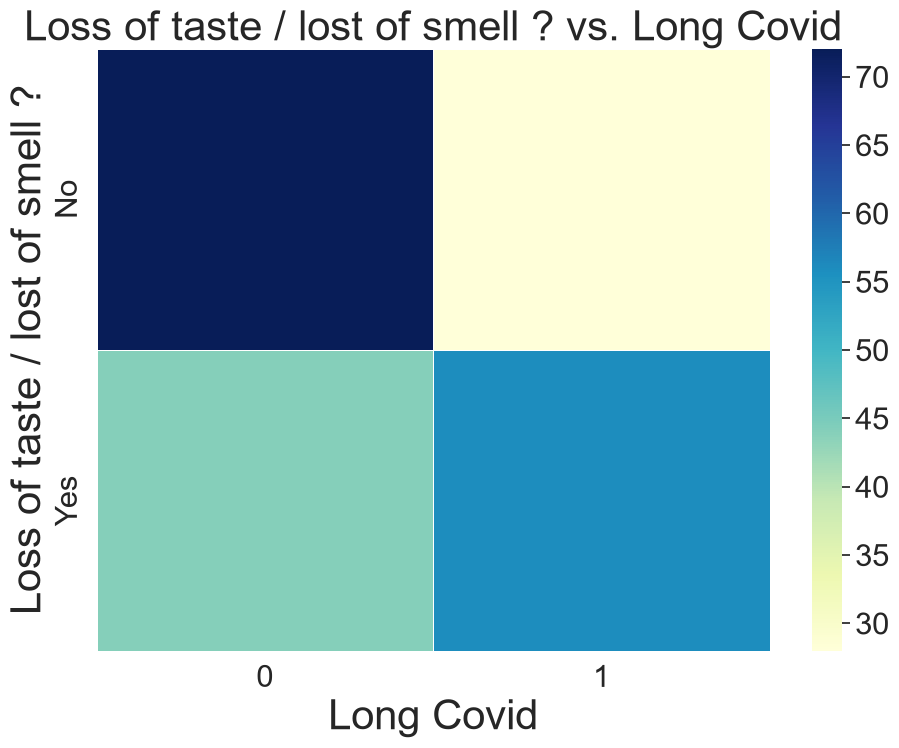

In [8]:
from ramen.Analysis import draw_heatmaps

draw_heatmaps(
    variables_against_target=   [ "Loss of taste / lost of smell ?"], # "Muscle aches (Myalgia) ?"
    target_node="Long Covid",
    csv="tutorial_data.csv",
)


## 7. Export the network for Cytoscape

Convert the final edge list to a directed graph, then use make_sif_file to export the network edges in SIF format and make_noa_file to export the node attributes in NOA format. Together, these files can be imported into Cytoscape for network visualization.

In [9]:
import networkx as nx
from ramen.Analysis import make_noa_file, make_sif_file

ramen_graph = nx.DiGraph(incoming_graph_data=ramen_results["FINAL_NETWORK"])
make_sif_file(
    nx_graph=ramen_graph,
    sif_name="tutorial_network.sif",
    visit_dict=ramen_bowl.edge_visit_dict,
    keep_factor=1,
)
make_noa_file(
    nx_graph=ramen_graph,
    noa_name="tutorial_network.noa",
    visit_dict=ramen_bowl.edge_visit_dict,
    end_var="Long Covid",
    classifications={},
)
